In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pylab as plt


df = pd.read_csv("data\\raw\\Video_Games_Sales.csv")
df.head()

,Name,Platform,Year_of_Release,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006.0,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
print("Numero righe e colonne:",df.shape)
print("Lista delle colonne: ", df.columns)

Numero righe e colonne: (16719, 16)
Lista delle colonne:  Index(['Name', 'Platform', 'Year_of_Release', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
       'Critic_Count', 'User_Score', 'User_Count', 'Developer', 'Rating'],
      dtype='str')


In [59]:
df.info()
df.describe()

print("Valori mancanti per colonna:")
print(df.isna().sum())

print("\nRighe duplicate:", df.duplicated().sum())



<class 'pandas.DataFrame'>
RangeIndex: 16719 entries, 0 to 16718
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16717 non-null  str    
 1   Platform         16719 non-null  str    
 2   Year_of_Release  16450 non-null  float64
 3   Genre            16717 non-null  str    
 4   Publisher        16665 non-null  str    
 5   NA_Sales         16719 non-null  float64
 6   EU_Sales         16719 non-null  float64
 7   JP_Sales         16719 non-null  float64
 8   Other_Sales      16719 non-null  float64
 9   Global_Sales     16719 non-null  float64
 10  Critic_Score     8137 non-null   float64
 11  Critic_Count     8137 non-null   float64
 12  User_Score       10015 non-null  str    
 13  User_Count       7590 non-null   float64
 14  Developer        10096 non-null  str    
 15  Rating           9950 non-null   str    
dtypes: float64(9), str(7)
memory usage: 2.0 MB
Valori mancanti per colonn

In [ ]:
df["Genre"].value_counts()

Genre
Action          3370
Sports          2348
Misc            1750
Role-Playing    1500
Shooter         1323
Adventure       1303
Racing          1249
Platform         888
Simulation       874
Fighting         849
Strategy         683
Puzzle           580
Name: count, dtype: int64

In [ ]:
df.dropna(subset=["Year_of_Release"], inplace=True)

df["Anno_di_uscita"] = pd.to_numeric(df["Anno_di_uscita"], errors="coerce").astype(int)

df.drop_duplicates(inplace=True)

df.rename(columns={
    "Genre": "Genere",
    "Year_of_Release": "Anno_di_uscita"
}, inplace=True)

df.head()


,Name,Platform,Anno_di_uscita,Genere,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN


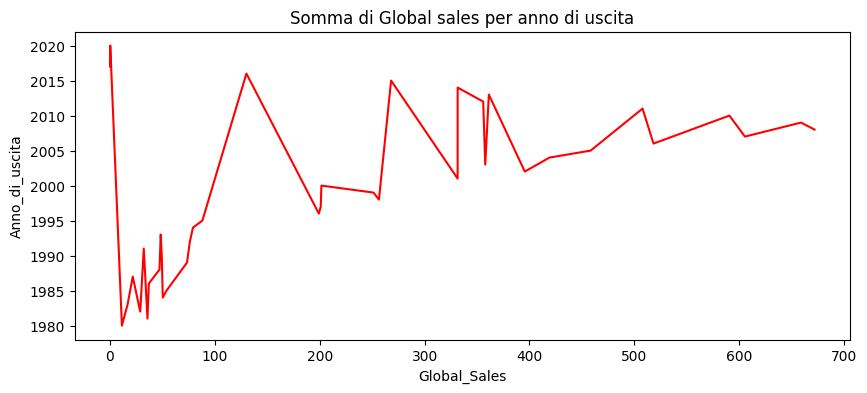

In [101]:
Global_sales_sum = df.groupby("Anno_di_uscita", as_index=False)["Global_Sales"].sum()
Global_sales_sum 


plt.figure(figsize=(10,4))
sns.lineplot(x = "Global_Sales", y = "Anno_di_uscita", data=Global_sales_sum, color="r").set(title="Somma di Global sales per anno di uscita")
plt.show()

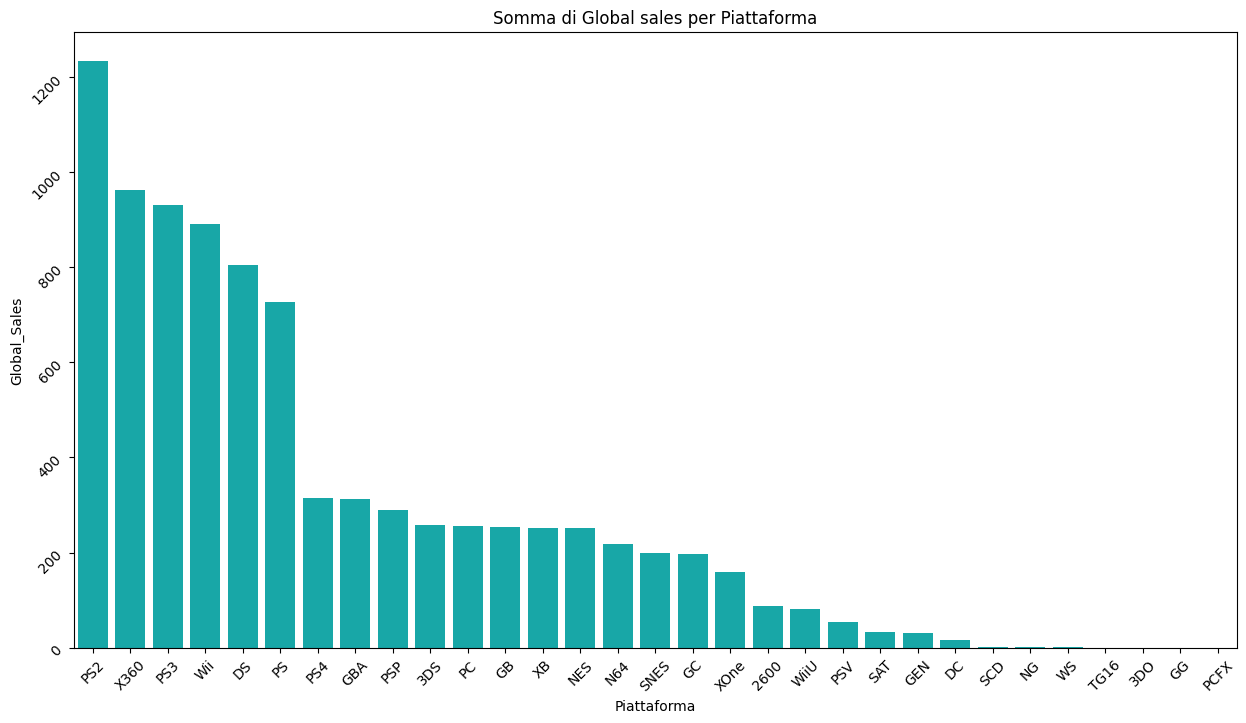

In [116]:
global_sales_platform = df.groupby("Platform", as_index=False)["Global_Sales"].sum().sort_values("Global_Sales",ascending=False)


plt.figure(figsize=(15,8))
plt.tick_params(axis="both",rotation=45)
sns.barplot(x="Platform",y="Global_Sales", data =global_sales_platform, color="c" ).set(title="Somma di Global sales per Piattaforma", xlabel="Piattaforma")
plt.tight_layout
plt.show()

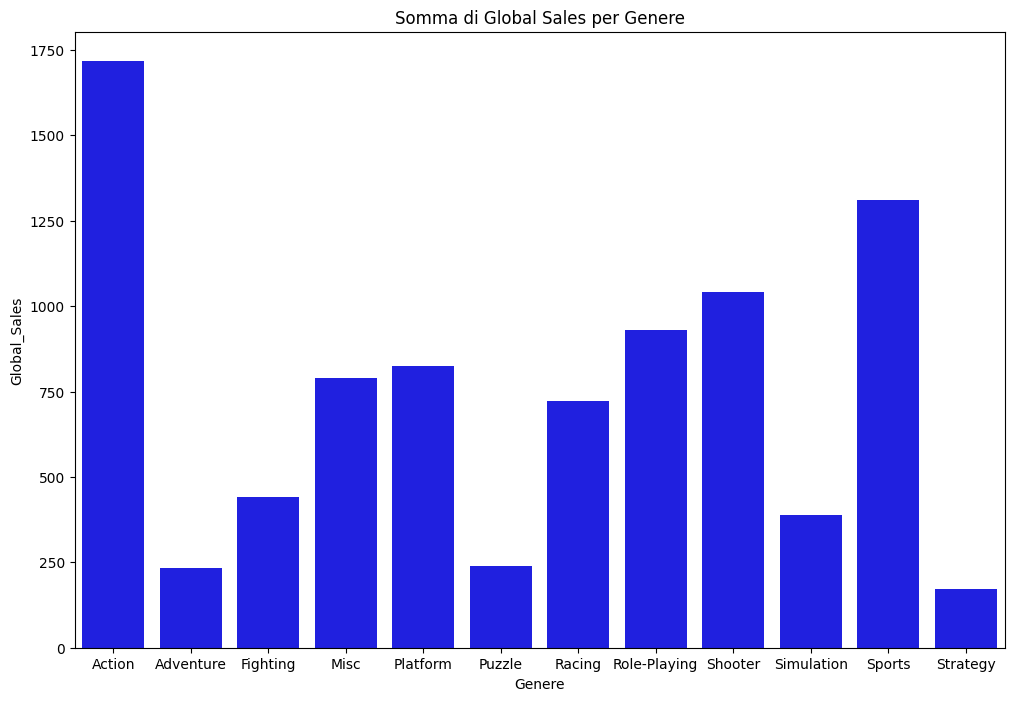

In [128]:
global_sales_genere = df.groupby("Genere", as_index=False)["Global_Sales"].sum()


plt.figure(figsize=(12,8))
sns.barplot(x="Genere",y="Global_Sales", data=global_sales_genere, color = "b").set(title="Somma di Global Sales per Genere")
plt.show()

In [138]:
top_10 = df.iloc[0:].sort_values(by="Global_Sales", ascending=False).head(10)
top_10

,Name,Platform,Anno_di_uscita,Genere,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Developer,Rating
0,Wii Sports,Wii,2006,Sports,Nintendo,41.36,28.96,3.77,8.45,82.53,76.0,51.0,8,322.0,Nintendo,E
1,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,NaN,NaN,NaN,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.68,12.76,3.79,3.29,35.52,82.0,73.0,8.3,709.0,Nintendo,E
3,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.61,10.93,3.28,2.95,32.77,80.0,73.0,8,192.0,Nintendo,E
4,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,NaN,NaN,NaN,NaN,NaN,NaN
5,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26,NaN,NaN,NaN,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.28,9.14,6.50,2.88,29.80,89.0,65.0,8.5,431.0,Nintendo,E
7,Wii Play,Wii,2006,Misc,Nintendo,13.96,9.18,2.93,2.84,28.92,58.0,41.0,6.6,129.0,Nintendo,E
8,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.44,6.94,4.70,2.24,28.32,87.0,80.0,8.4,594.0,Nintendo,E
9,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31,NaN,NaN,NaN,NaN,NaN,NaN


In [141]:
top_10_publisher = df.groupby("Publisher", as_index=False)["Global_Sales"].sum().sort_values("Global_Sales",ascending=False).reset_index().head(10)
top_10_publisher

,index,Publisher,Global_Sales
0,361,Nintendo,1786.72
1,139,Electronic Arts,1100.05
2,21,Activision,725.14
3,457,Sony Computer Entertainment,606.27
4,527,Ubisoft,470.45
5,496,Take-Two Interactive,403.58
6,490,THQ,338.11
7,277,Konami Digital Entertainment,277.36
8,447,Sega,268.11
9,349,Namco Bandai Games,254.19


In [160]:
piattaforme =df.query("Platform in ['PS2', 'Wii','X360']").groupby(["Anno_di_uscita","Platform"], as_index=False)["Global_Sales"].mean().sort_values(["Platform","Anno_di_uscita"])
piattaforme



,Anno_di_uscita,Platform,Global_Sales
0,2000,PS2,0.476951
1,2001,PS2,0.899622
2,2002,PS2,0.733571
3,2003,PS2,0.719883
4,2004,PS2,0.817683
5,2005,PS2,0.617885
7,2006,PS2,0.399305
10,2007,PS2,0.355140
13,2008,PS2,0.281832
16,2009,PS2,0.275521


In [180]:
print("1I generi più venduti sono Action, Sports e Shooter Questi tre generi dominano il mercato globale, con vendite nettamente superiori rispetto a generi come" "\n"\
"Puzzle, Strategy o Adventure.Il genere Action è quello più costante nel tempo.\n" 
"Le piattaforme più redditizie sono PS2, Wii e X360La PS2 risulta la piattaforma con il maggior volume di vendite globali nella storia del dataset.\n" \
"La Wii ha un picco molto forte negli anni 2007–2011, mentre Xbox 360 mantiene vendite elevate per diversi anni consecutivi.")


print("5. I publisher più forti sono Nintendo, Electronic Arts e Activision. \nQuesti tre publisher generano la maggior parte delle vendite globali." \
"Nintendo domina soprattutto grazie ai titoli per Wii e DS." \
"I giochi più venduti appartengono spesso \na franchise famosi" \
"I top 10 giochi globali includono titoli come Wii Sports, Mario Kart, Call of Duty, Pokémon.\n" \
"Questo conferma che i franchise consolidati hanno un impatto enorme sulle vendite.")

1I generi più venduti sono Action, Sports e Shooter Questi tre generi dominano il mercato globale, con vendite nettamente superiori rispetto a generi come
Puzzle, Strategy o Adventure.Il genere Action è quello più costante nel tempo.
Le piattaforme più redditizie sono PS2, Wii e X360La PS2 risulta la piattaforma con il maggior volume di vendite globali nella storia del dataset.
La Wii ha un picco molto forte negli anni 2007–2011, mentre Xbox 360 mantiene vendite elevate per diversi anni consecutivi.
5. I publisher più forti sono Nintendo, Electronic Arts e Activision. 
Questi tre publisher generano la maggior parte delle vendite globali.Nintendo domina soprattutto grazie ai titoli per Wii e DS.I giochi più venduti appartengono spesso 
a franchise famosiI top 10 giochi globali includono titoli come Wii Sports, Mario Kart, Call of Duty, Pokémon.
Questo conferma che i franchise consolidati hanno un impatto enorme sulle vendite.
